### Discutere l’approssimazione a m dati equispaziati ottenuti campionando la funzione f(x) = 1/1+25*x^2 nell’intervallo [−1,1] usando polinomi di grado n ∈ {1,2,3,5,7}.
### Si risolva il problema dei minimi quadrati sia mediante le equazioni normali che con SVD, calcolando l’er- rore di approssimazione in norma 2 per entrambi i metodi. Infine graficare le approssimazioni polinomiali ottenute

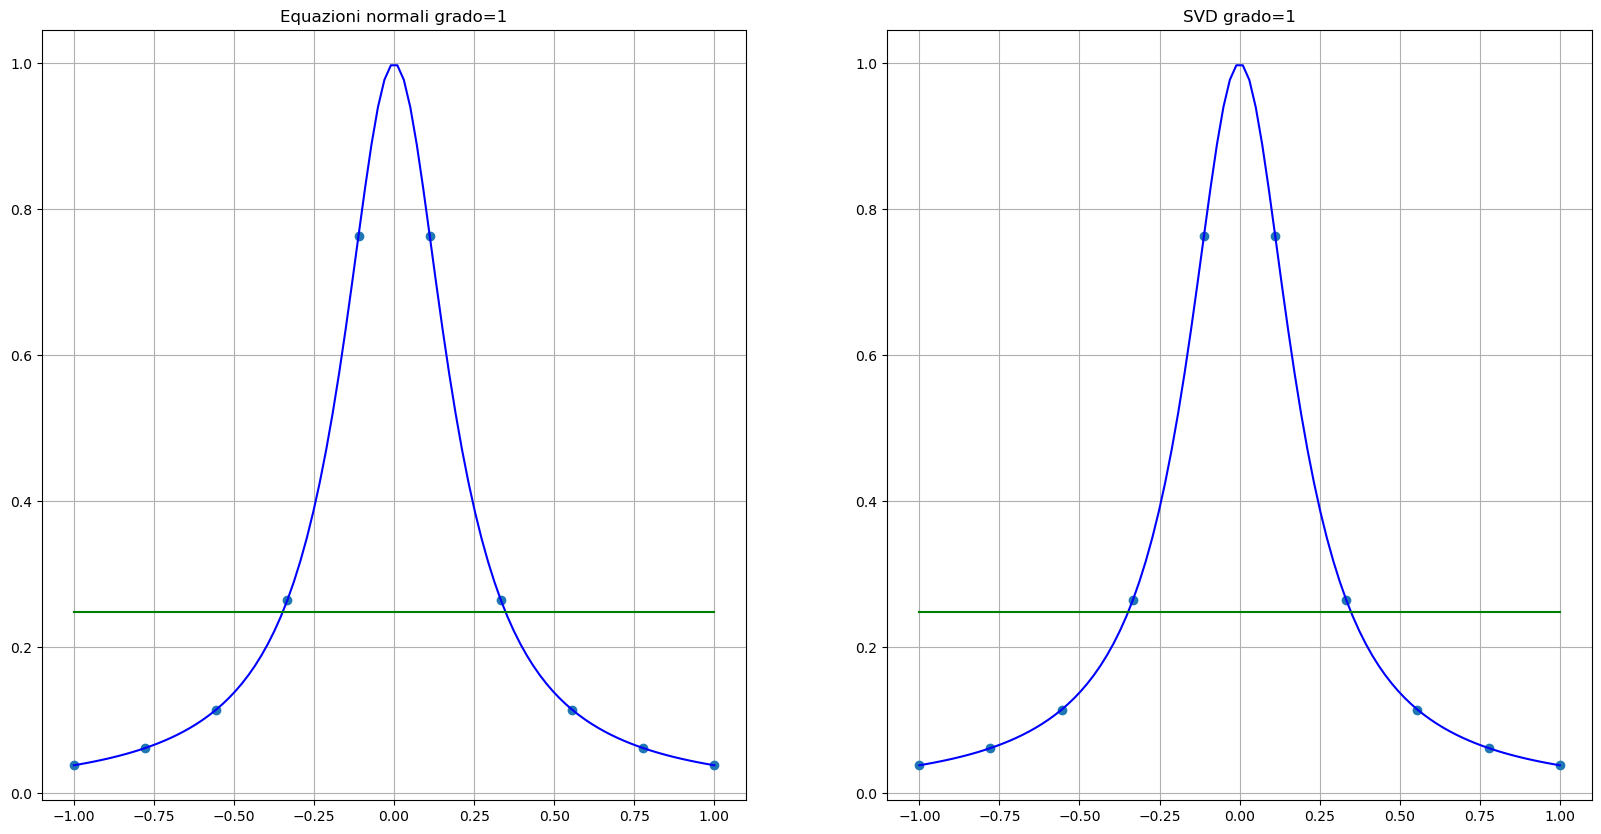

Errore di approssimazione con Eq. Normali (Grado 1):  0.8519889898800778
Errore di approssimazione con SVD (Grado 1):  0.8519889898800777 



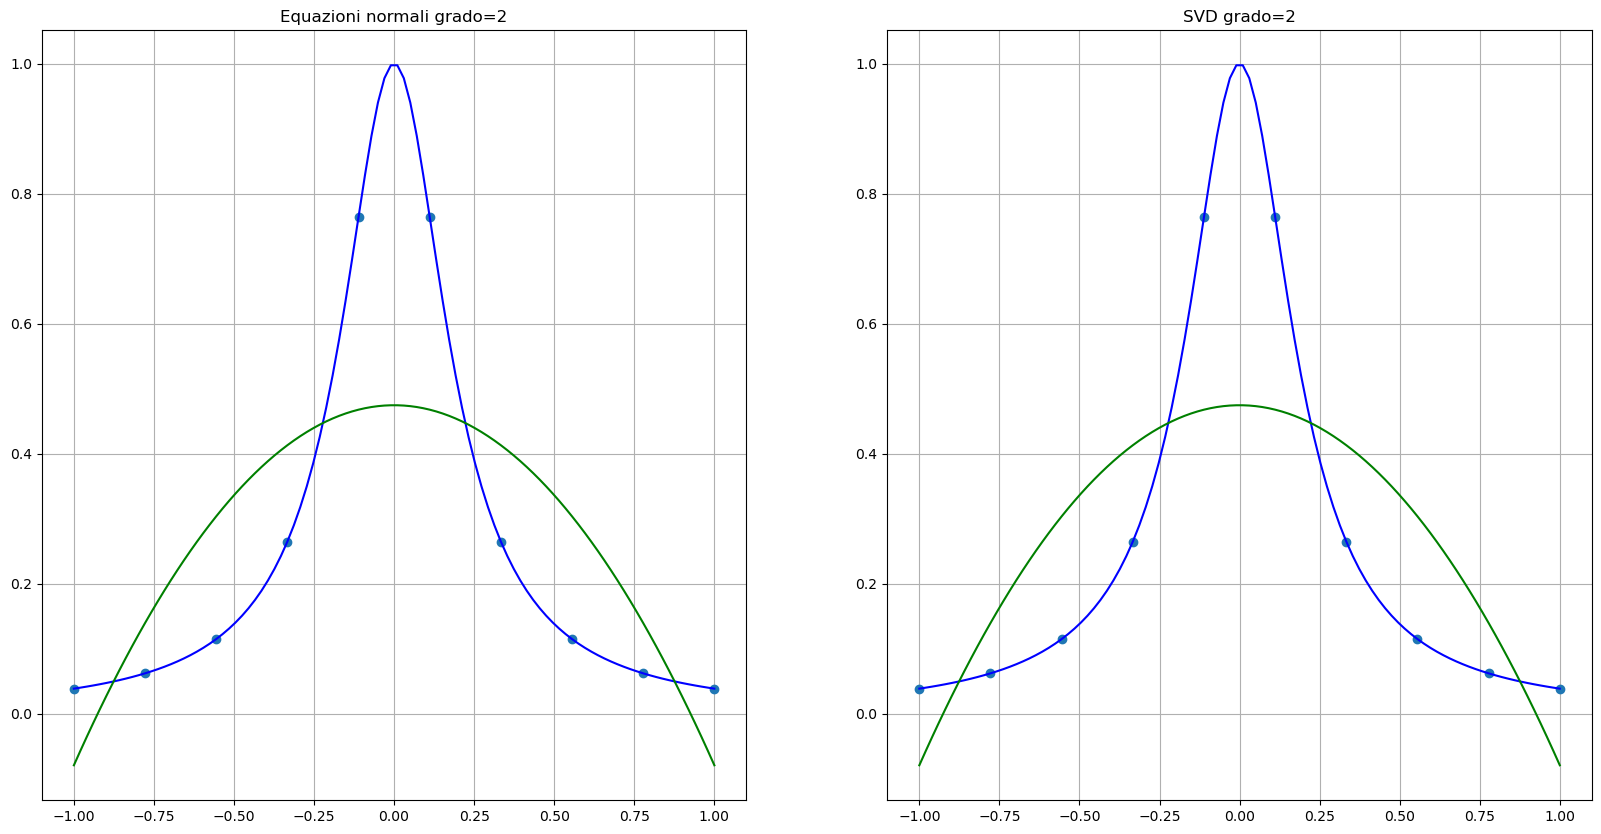

Errore di approssimazione con Eq. Normali (Grado 2):  0.5751808755886042
Errore di approssimazione con SVD (Grado 2):  0.5751808755886042 



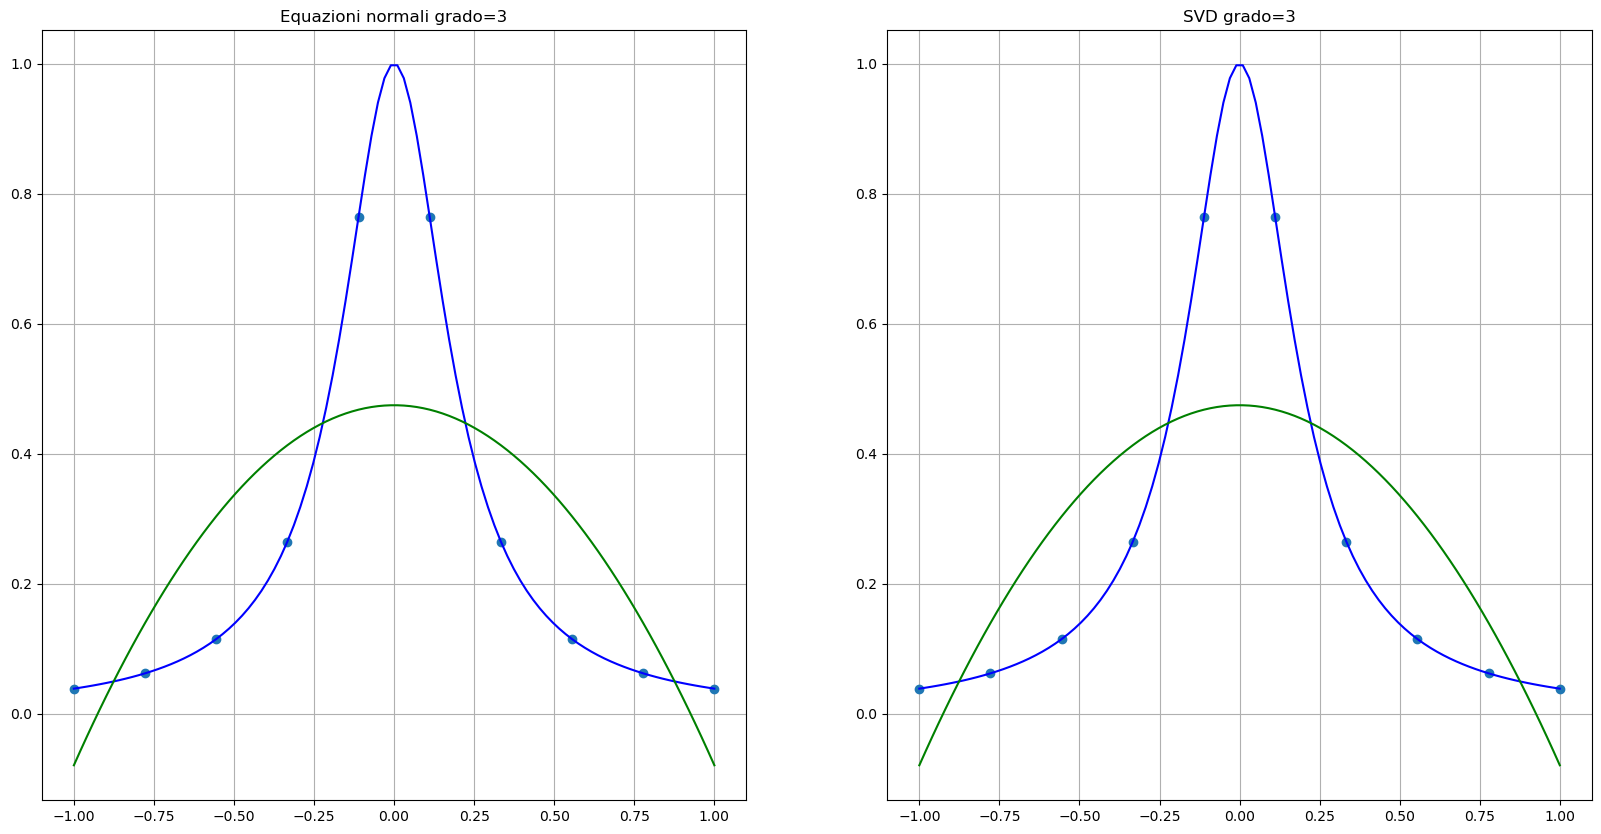

Errore di approssimazione con Eq. Normali (Grado 3):  0.5751808755886041
Errore di approssimazione con SVD (Grado 3):  0.5751808755886042 



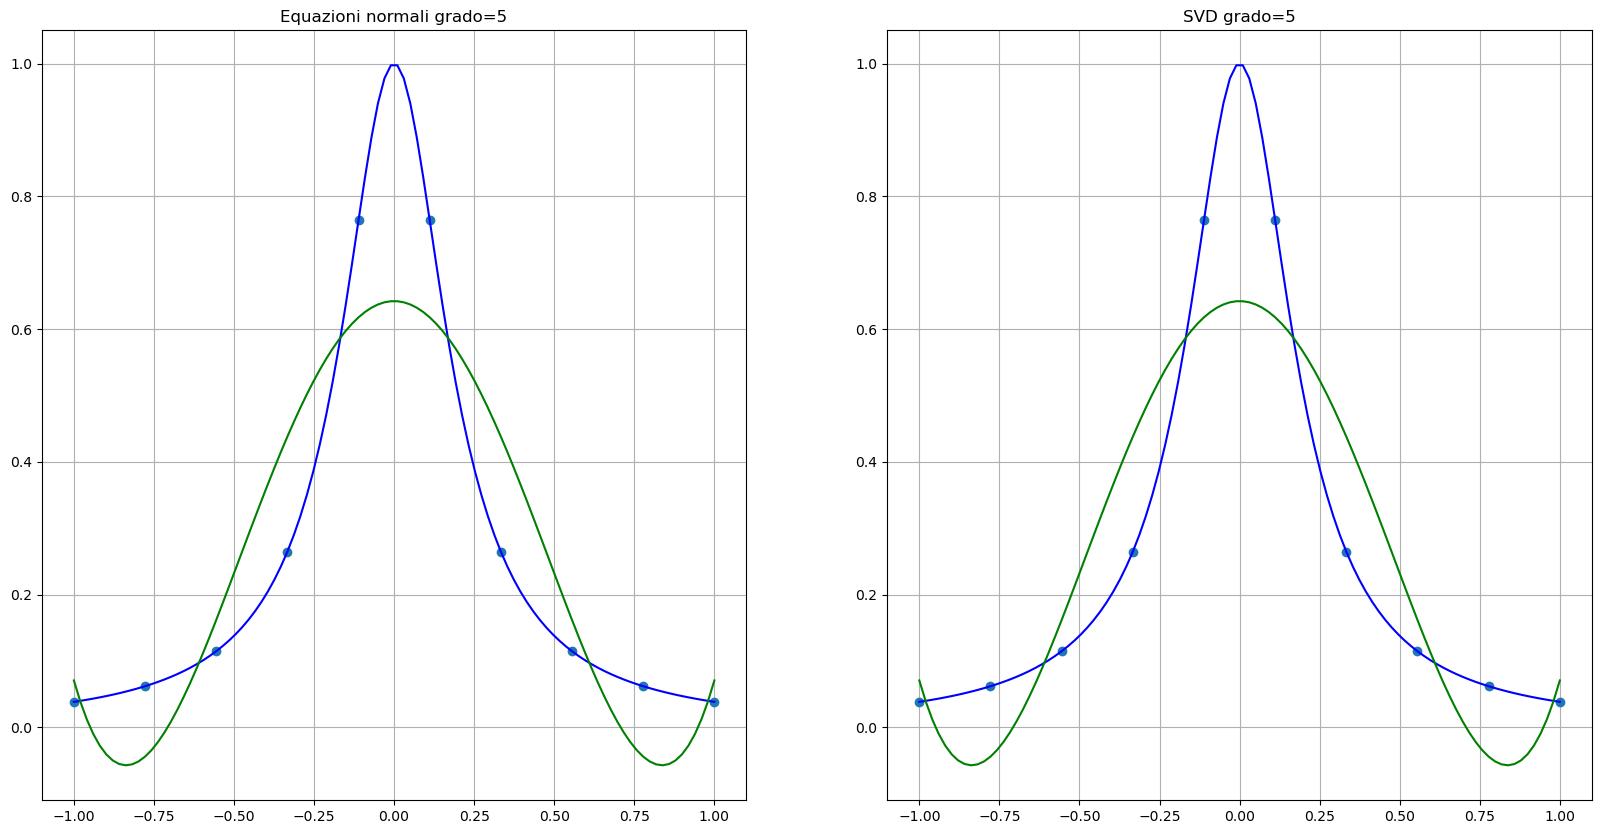

Errore di approssimazione con Eq. Normali (Grado 5):  0.3631838354754461
Errore di approssimazione con SVD (Grado 5):  0.3631838354754461 



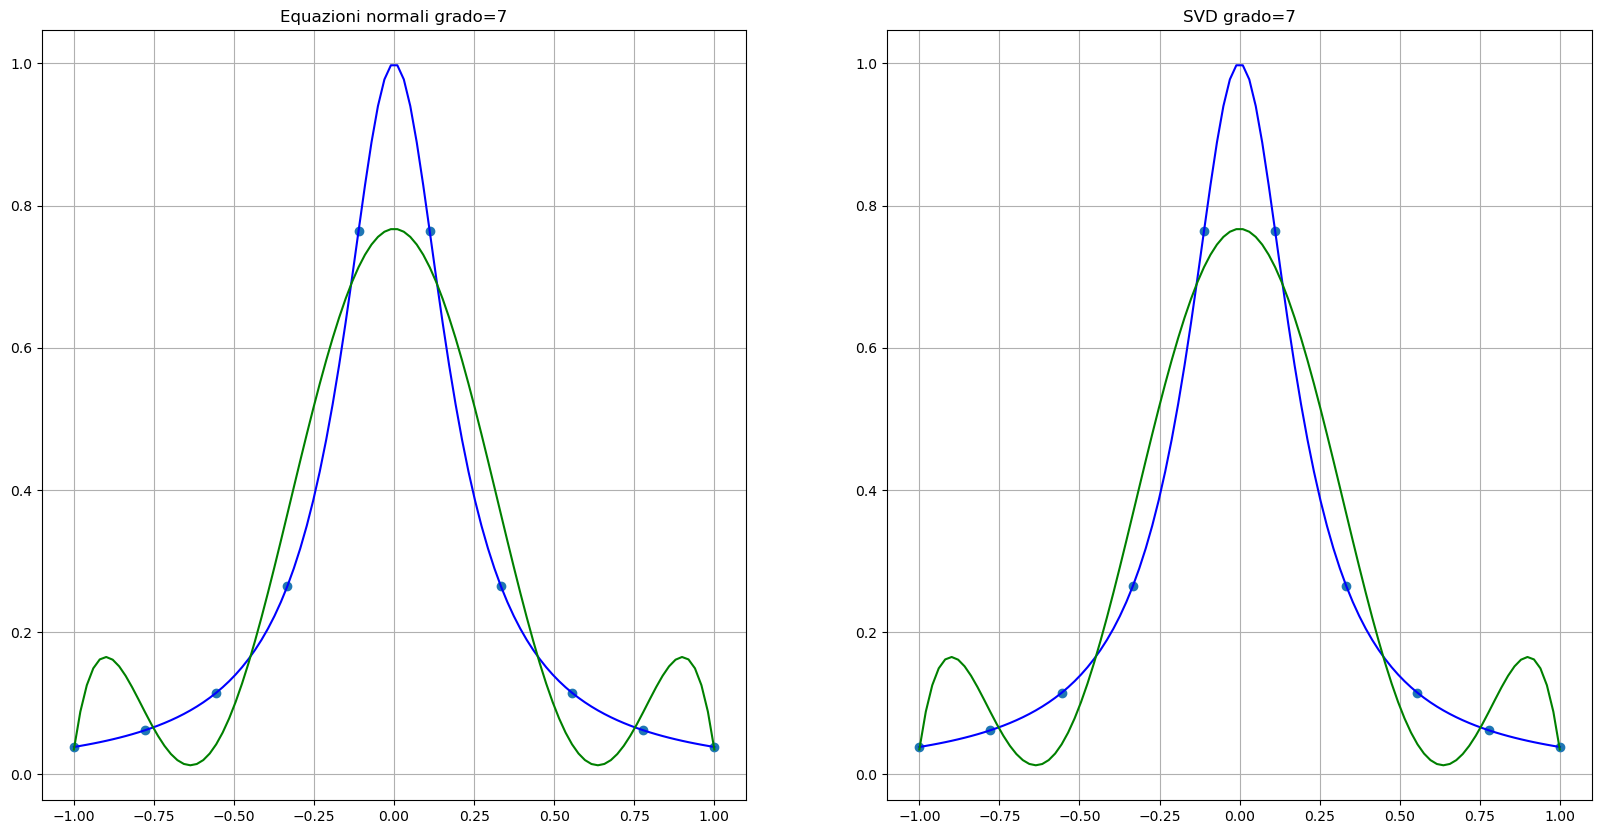

Errore di approssimazione con Eq. Normali (Grado 7):  0.19391838466015754
Errore di approssimazione con SVD (Grado 7):  0.19391838466015768 



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.linalg
from scipy.linalg import lu_factor as LUdec 
  
case = 1
m = 10 
m_plot = 100 


if case==0:
    x = np.linspace(-1,1,m) 
    y = np.exp(x/2)
    f = lambda x: np.exp(x*(1/2)) 
elif case==1:
    x = np.linspace(-1,1,m)
    y = 1/(1+25*(x**2))
    f = lambda x: 1/(1+25*(x**2))
elif case==2:
    x = np.linspace(0,2*np.pi,m) 
    y = np.sin(x)+np.cos(x)
    f = lambda x: np.sin(x)+ np.cos(x)
    
    
for n in [1, 2, 3, 5, 7]: 
    A = np.zeros((m, n+1)) 
   
    
    for i in range(n+1):
        A[:, i] = x**i
   
    U, s, Vh = scipy.linalg.svd(A) 
    alpha_svd = np.zeros(n+1) 
   
    for i in range(n+1): 
        ui = U[:, i]
        vi = Vh[i, :]
        alpha_svd = alpha_svd + np.dot(ui, y) * vi /s[i] 


    x_plot = np.linspace(x[0], x[-1], m_plot) 
    A_plot = np.zeros((m_plot, n+1)) 

    for i in range(n+1): 
        A_plot[:, i] = x_plot**i

    y_interpolationSVD = A_plot @ alpha_svd 
    
    
    ATA = A.T@A
    ATy = A.T@y
    
    L = scipy.linalg.cholesky(ATA) 
    z = scipy.linalg.solve_triangular(np.transpose(L), ATy, lower=True) 
    alpha_chol = scipy.linalg.solve_triangular(L, z, lower=False)
    
    y_interpolationChol = A_plot @ alpha_chol 

    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    plt.title(f"Equazioni normali grado={i}")
    plt.plot(x, y, 'o')
    plt.plot(x_plot, f(x_plot), 'blue')
    plt.plot(x_plot, y_interpolationChol, label=f"Risoluzione con EQ normali, grado={i}", color='green')
    plt.grid()
    
    plt.subplot(1, 2, 2)
    plt.title(f"SVD grado={i}")
    plt.plot(x, y, 'o')
    plt.plot(x_plot, f(x_plot), 'blue')
    plt.plot(x_plot, y_interpolationSVD, label=f"Risoluzione con SVD, grado={i}", color='green')
    plt.grid()
    plt.show()
    
    err1 = np.linalg.norm(A @ alpha_svd - y, 2)
    err2 = np.linalg.norm(A @ alpha_chol - y, 2)
    print (f'Errore di approssimazione con Eq. Normali (Grado {i:n}): ', err1)
    print (f'Errore di approssimazione con SVD (Grado {i:n}): ', err2, '\n')